# Model Selection
Training and comparing baseline Random Forest and XGBoost models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [ ]:
# Model 1: Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [ ]:
# Model 2: AI-recommended - XGBoost
print("Training XGBoost (AI-recommended model)...")
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

Training XGBoost (AI-recommended model)...


In [ ]:
def evaluate(y_true, y_pred, name, label='Baseline - No Refinement'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'\n=== {name} ({label}) ===')
    print(f'MAE:   {mae:.2f}')
    print(f'RMSE:  {rmse:.2f}')
    print(f'R²:    {r2:.4f}')
    return mae, rmse, r2

mae_rf_base,  rmse_rf_base,  r2_rf_base  = evaluate(y_test, rf_pred,  'Random Forest')
mae_xgb_base, rmse_xgb_base, r2_xgb_base = evaluate(y_test, xgb_pred, 'XGBoost')


In [ ]:
print("MODEL COMPARISON")
print(f"{'Metric':<6} {'Random Forest':<18} {'XGBoost':<18}")
print(f"MAE    {mae_rf:<18.2f} {mae_xgb:<18.2f}")
print(f"RMSE   {rmse_rf:<18.2f} {rmse_xgb:<18.2f}")
print(f"R²     {r2_rf:<18.4f} {r2_xgb:<18.4f}")

MODEL COMPARISON
Metric Random Forest      XGBoost           
MAE    26.81              27.27             
RMSE   34.93              35.56             
R²     0.2903             0.2644            


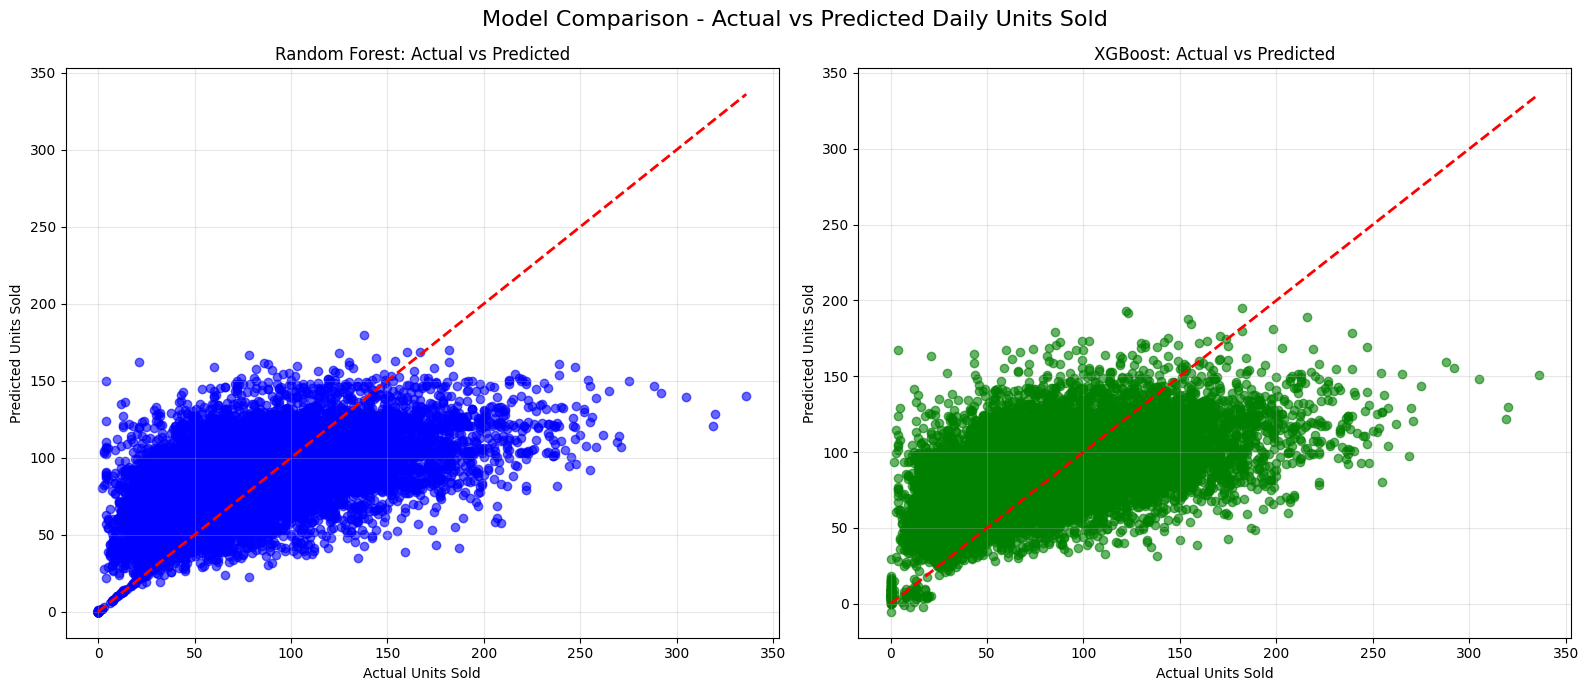

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest
axes[0].scatter(y_test, rf_pred, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Units Sold')
axes[0].set_ylabel('Predicted Units Sold')
axes[0].set_title('Random Forest: Actual vs Predicted')
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].scatter(y_test, xgb_pred, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Units Sold')
axes[1].set_ylabel('Predicted Units Sold')
axes[1].set_title('XGBoost: Actual vs Predicted')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Comparison - Actual vs Predicted Daily Units Sold', fontsize=16)
plt.tight_layout()
plt.show()

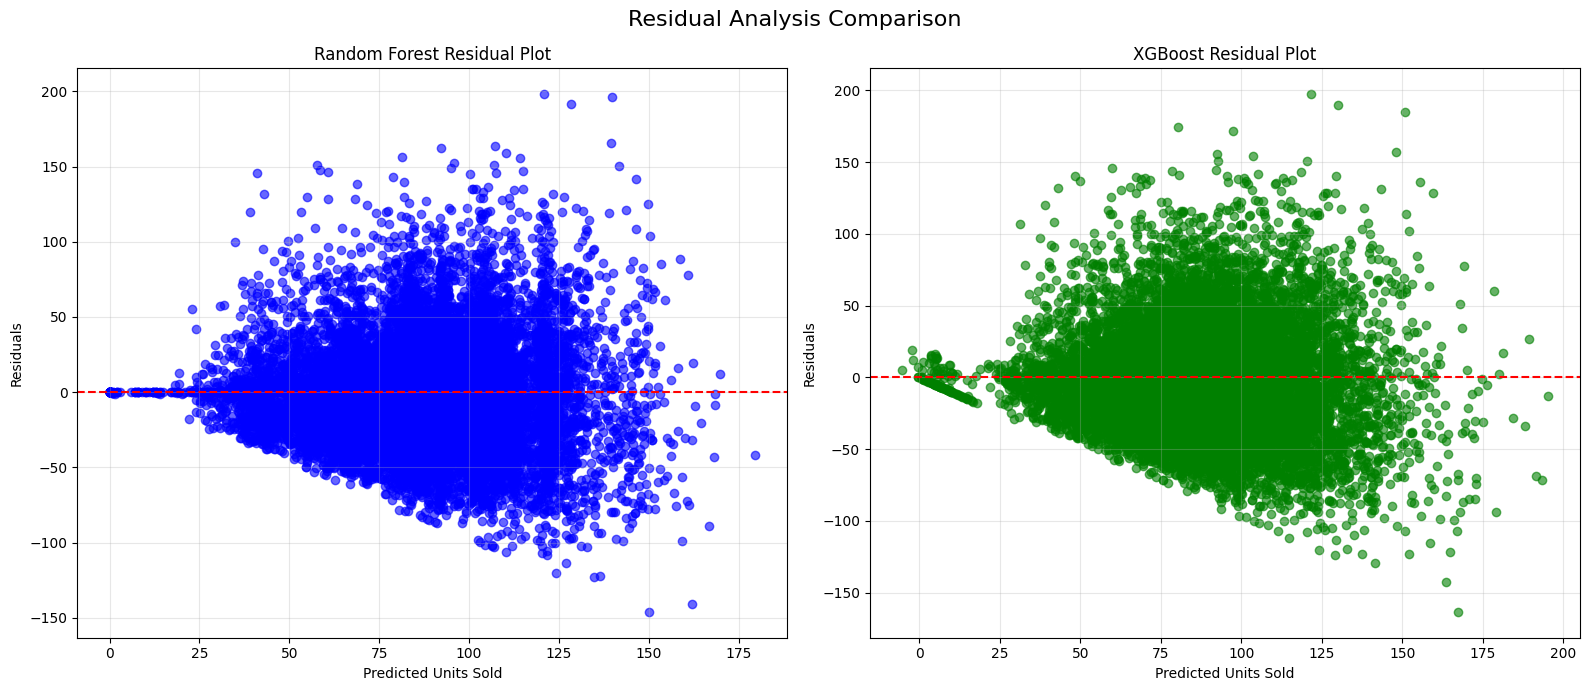

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Random Forest Residuals
rf_residuals = y_test - rf_pred
axes[0].scatter(rf_pred, rf_residuals, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predicted Units Sold')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Random Forest Residual Plot')
axes[0].grid(True, alpha=0.3)

# XGBoost Residuals
xgb_residuals = y_test - xgb_pred
axes[1].scatter(xgb_pred, xgb_residuals, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Predicted Units Sold')
axes[1].set_ylabel('Residuals')
axes[1].set_title('XGBoost Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis Comparison', fontsize=16)
plt.tight_layout()
plt.show()